# Week 4 - Baseline Linear Regression

**Goal:** train and evaluate a Linear Regression baseline for California
`Residential` / `SingleFamilyResidence` close prices.

**Data source:** the team's Week 3 model-ready files from the shared Google Drive.
The team-selected 12-month training window is May 2025-April 2026; May 2026 is
held out as the test month.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "ClosePrice"
TRAIN_PATH = Path("data/week3_drive/crmls_sfr_train_X12_2025-05_to_2026-04.csv")
TEST_PATH = Path("data/week3_drive/crmls_sfr_test_2026-05.csv")
OUTPUT_DIR = Path("outputs/week4_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load the Week 3 train/test outputs

Week 4 uses the team's existing split directly; it does not re-clean, re-encode,
or re-split the data.

In [2]:
if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError(
        "Download the two model-ready CSVs from Google Drive > IDX Summer Intern > outputs "
        "into data/week3_drive before running this notebook."
    )

train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

assert train_df["split"].eq("train").all()
assert test_df["split"].eq("test").all()
assert train_df["close_month"].min() == "2025-05"
assert train_df["close_month"].max() == "2026-04"
assert test_df["close_month"].eq("2026-05").all()
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train months:", train_df["close_month"].min(), "to", train_df["close_month"].max())
print("Test month:", test_df["close_month"].unique().tolist())

Train shape: (129745, 153)
Test shape: (12012, 153)
Train months: 2025-05 to 2026-04
Test month: ['2026-05']


## 2. Leakage rules

`ListPrice`, `OriginalListPrice`, and `ClosePrice_to_ListPrice_ratio` are excluded.
They reveal pricing information unavailable for the intended off-market valuation
use case. Identifiers and date/split fields are also excluded.

In [3]:
forbidden = {
    "ClosePrice", "ListPrice", "OriginalListPrice", "ListPrice_scaled",
    "ClosePrice_to_ListPrice_ratio", "ListingKey", "ListingKeyNumeric",
    "ListingId", "CloseDate", "close_month", "source_month", "split",
}

feature_bundles = {
    "M1_size_only": ["LivingArea_scaled"],
    "M2_basic_structure": [
        "LivingArea_scaled", "BedroomsTotal_scaled", "YearBuilt_scaled",
        "LotSizeSquareFeet_scaled",
    ],
    "M3_structure_with_bathrooms": [
        "LivingArea_scaled", "BedroomsTotal_scaled", "YearBuilt_scaled",
        "LotSizeSquareFeet_scaled", "BathroomsTotalInteger_scaled",
    ],
    "M4_structure_location": [
        "LivingArea_scaled", "BedroomsTotal_scaled", "YearBuilt_scaled",
        "LotSizeSquareFeet_scaled", "BathroomsTotalInteger_scaled",
        "Latitude_scaled", "Longitude_scaled", "PostalCode_frequency", "City_frequency",
    ],
    "M5_expanded_non_leaky": [
        "LivingArea_scaled", "BedroomsTotal_scaled", "YearBuilt_scaled",
        "LotSizeSquareFeet_scaled", "BathroomsTotalInteger_scaled",
        "Latitude_scaled", "Longitude_scaled", "PostalCode_frequency", "City_frequency",
        "AssociationFee_scaled", "Stories_scaled", "GarageSpaces_scaled",
        "DaysOnMarket_scaled", "HighSchoolDistrict_frequency",
    ],
}

for name, cols in feature_bundles.items():
    assert not forbidden.intersection(cols), f"Leakage found in {name}"
    assert set(cols).issubset(train_df.columns) and set(cols).issubset(test_df.columns)
    assert not train_df[cols].isna().any().any(), f"Missing training values in {name}"
    assert not test_df[cols].isna().any().any(), f"Missing test values in {name}"

## 3. Training-set feature screening

Correlations are calculated on training data only. They describe association, not
causation. Frequency encodings measure category prevalence, not neighborhood or
school quality.

In [4]:
all_candidates = list(dict.fromkeys(c for cols in feature_bundles.values() for c in cols))
target_correlations = (
    train_df[all_candidates + [TARGET]].corr(numeric_only=True)[TARGET]
    .drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
)
display(target_correlations.to_frame("train_correlation_with_ClosePrice").round(4))

,train_correlation_with_ClosePrice
LivingArea_scaled,0.6204
BathroomsTotalInteger_scaled,0.5533
BedroomsTotal_scaled,0.3214
AssociationFee_scaled,0.1617
PostalCode_frequency,-0.1307
HighSchoolDistrict_frequency,0.1191
Stories_scaled,0.1078
Longitude_scaled,-0.0847
GarageSpaces_scaled,0.0571
City_frequency,0.0498


In [5]:
x_corr = train_df[all_candidates].corr().abs()
high_corr_pairs = []
for i, feature_a in enumerate(all_candidates):
    for feature_b in all_candidates[i + 1:]:
        value = x_corr.loc[feature_a, feature_b]
        if value >= 0.80:
            high_corr_pairs.append((feature_a, feature_b, value))
display(pd.DataFrame(high_corr_pairs, columns=["feature_a", "feature_b", "abs_corr"]).round(4))

,feature_a,feature_b,abs_corr
0,LivingArea_scaled,BathroomsTotalInteger_scaled,0.8400
1,Latitude_scaled,Longitude_scaled,0.9249


## 4. Train and evaluate five Linear Regression baselines

R2 is the required Week 4 metric. MAPE and MdAPE are included as supporting
percentage-error measures. Final selection uses the untouched May 2026 test set.

In [6]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    valid = y_true != 0
    return np.mean(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid]))


def mdape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    valid = y_true != 0
    return np.median(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid]))


results, fitted_models, predictions = [], {}, {}
y_train, y_test = train_df[TARGET], test_df[TARGET]

for model_name, features in feature_bundles.items():
    model = LinearRegression()
    model.fit(train_df[features], y_train)
    train_pred = model.predict(train_df[features])
    test_pred = model.predict(test_df[features])
    fitted_models[model_name] = model
    predictions[model_name] = test_pred
    results.append({
        "model": model_name,
        "n_features": len(features),
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "test_rmse": mean_squared_error(y_test, test_pred) ** 0.5,
        "test_mape": mape(y_test, test_pred),
        "test_mdape": mdape(y_test, test_pred),
    })

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,model,n_features,train_r2,test_r2,test_mae,test_rmse,test_mape,test_mdape
0,M5_expanded_non_leaky,14,0.5078,0.5371,504340.0194,9.240315e+05,0.4934,0.3284
1,M4_structure_location,9,0.4964,0.5285,512983.5385,9.326067e+05,0.5050,0.3377
2,M3_structure_with_bathrooms,5,0.4583,0.4792,548238.0341,9.801832e+05,0.5309,0.3611
3,M2_basic_structure,4,0.4419,0.4648,552576.9046,9.936221e+05,0.5356,0.3537
4,M1_size_only,1,0.3849,0.4021,614774.4151,1.050205e+06,0.5974,0.4173


## 5. Select and save the Week 4 baseline

In [7]:
best_name = results_df.loc[0, "model"]
best_model = fitted_models[best_name]
best_features = feature_bundles[best_name]
best_pred = predictions[best_name]

results_df.to_csv(OUTPUT_DIR / "baseline_model_comparison.csv", index=False)
pd.DataFrame({
    "actual_close_price": y_test.to_numpy(),
    "predicted_close_price": best_pred,
    "residual": y_test.to_numpy() - best_pred,
}).to_csv(OUTPUT_DIR / "baseline_test_predictions.csv", index=False)
joblib.dump({"model": best_model, "features": best_features}, OUTPUT_DIR / "linear_regression_baseline.joblib")

metadata = {
    "data_source": "Google Drive/IDX Summer Intern/outputs",
    "train_file": TRAIN_PATH.name,
    "test_file": TEST_PATH.name,
    "selected_model": best_name,
    "features": best_features,
    **results_df.iloc[0].to_dict(),
}
with open(OUTPUT_DIR / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Selected baseline:", best_name)
print("Test R2:", round(float(results_df.loc[0, "test_r2"]), 4))
print("Saved outputs to:", OUTPUT_DIR.resolve())

Selected baseline: M5_expanded_non_leaky
Test R2: 0.5371
Saved outputs to: /Users/apple/Documents/DS Summer Intern/outputs/week4_baseline


## 6. Actual vs. predicted diagnostic

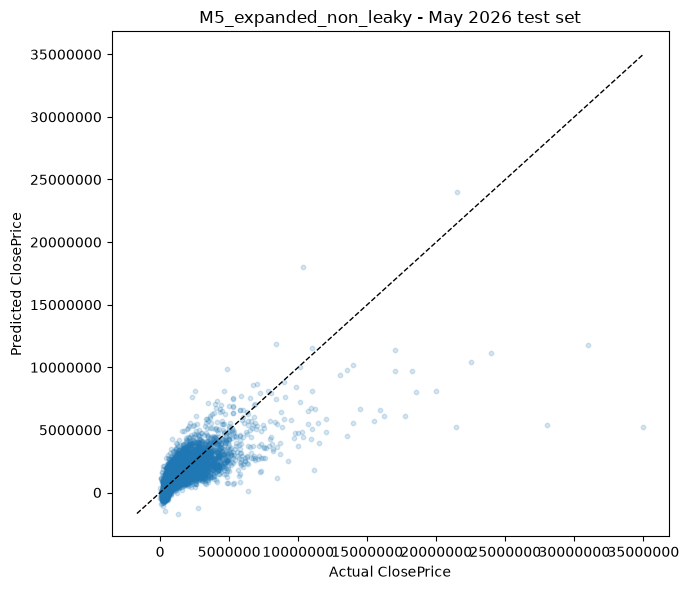

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_pred, alpha=0.18, s=10)
low, high = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
ax.plot([low, high], [low, high], "--", color="black", linewidth=1)
ax.set(
    xlabel="Actual ClosePrice", ylabel="Predicted ClosePrice",
    title=f"{best_name} - May 2026 test set",
)
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted.png", dpi=160)
plt.show()

## Conclusion

The highest May 2026 test R2 in the comparison table is the official Week 4
baseline. It is a reproducible benchmark, not a production valuation model.
Linear Regression cannot fully capture nonlinear price effects or neighborhood
interactions. Week 5 should test Decision Tree and Random Forest models using the
exact same team train/test files so the comparison remains fair.